# E01 · The Bayesian workflow in PyMC 6

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Howell's !Kung census: height, weight, age and sex of 544 people |
| **You will learn** | The full modelling loop in current PyMC: `coords`/`dims` · `pm.Data` · prior predictive checks · sampling · reading a `DataTree` · diagnostics · posterior predictive checks · predicting for new inputs |

Every challenge in this repository assumes you can do what is on this page without thinking.
It is also a tour of what **changed** if you learned PyMC a few versions ago:

| Then | Now (PyMC 6 / ArviZ 1) |
|---|---|
| `pm.sample` returns `InferenceData` | returns an xarray **`DataTree`**; groups work the same (`idata.posterior["x"]`) |
| `pm.MutableData`, `pm.ConstantData` | just **`pm.Data`** |
| `az.plot_posterior`, `az.plot_ppc` | **`az.plot_dist`**, **`az.plot_ppc_dist`** (and a family of `plot_ppc_*`) |
| `az.summary` shows 94% HDI | shows an **89% equal-tailed interval** by default; ask for what you want with `ci_kind=`, `ci_prob=` |
| plots return matplotlib axes | plots return a **`PlotCollection`** |
| `pm.sample` uses PyMC's NUTS | uses **nutpie** automatically when it is installed |

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · Question and data

*How does height depend on weight among adults, and does it differ by sex?* A deliberately
simple question, so the workflow is the star.

In [2]:
data.describe("howell")
howell = data.load("howell")
adults = howell[howell.age >= 18].reset_index(drop=True)
adults["sex"] = np.where(adults.male == 1, "male", "female")
adults.describe().round(1)

howell: Height (cm), weight (kg), age and sex of 544 individuals.
  source: Nancy Howell's Dobe !Kung census (1960s), via McElreath's `rethinking`.
  url:    https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Howell1.csv


,height,weight,age,male
count,352.0,352.0,352.0,352.0
mean,154.6,45.0,41.1,0.5
std,7.7,6.5,16.0,0.5
min,136.5,31.1,18.0,0.0
25%,148.6,40.3,28.0,0.0
50%,154.3,44.8,39.0,0.0
75%,160.7,49.3,51.0,1.0
max,179.1,63.0,88.0,1.0


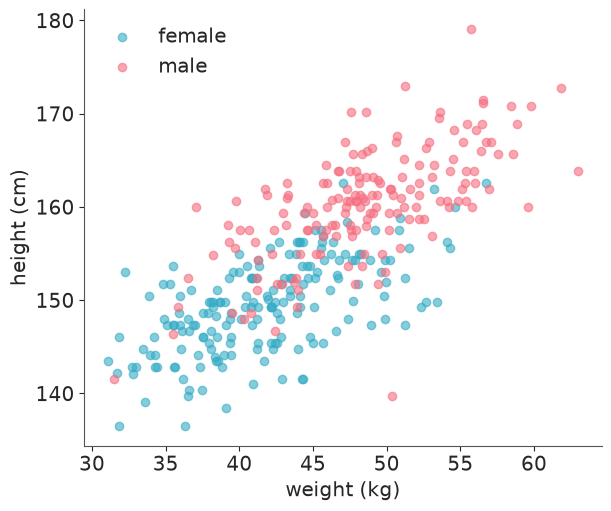

In [3]:
fig, ax = plt.subplots()
for sex, grp in adults.groupby("sex"):
    ax.scatter(grp.weight, grp.height, label=sex, alpha=0.6)
ax.set(xlabel="weight (kg)", ylabel="height (cm)")
ax.legend();

## 2 · Write the model down

$$
\begin{aligned}
\text{height}_i &\sim \text{Normal}(\mu_i, \sigma) \\
\mu_i &= \alpha_{\text{sex}[i]} + \beta\,(\text{weight}_i - \bar{w})
\end{aligned}
$$

Centring weight makes $\alpha$ "the height of a person of average weight", which is something
we can put a prior on from general knowledge: adults are roughly 150-180 cm. For $\beta$,
one extra kilogram is not going to add 10 cm; `Normal(0, 1)` cm/kg is generous. We will
**check** those claims rather than trust them.

Three habits worth forming, all visible below:

- **`coords` and `dims`** name the axes of your model. Every output is then labelled, and
  you index by `"female"` instead of `0`.
- **`pm.Data`** registers inputs with the model so you can swap them later for prediction.
- Index variables (`alpha[sex_idx]`) instead of dummy columns - they scale to hierarchies.

In [4]:
sex_idx, sexes = pd.factorize(adults.sex, sort=True)
weight_mean = adults.weight.mean()

coords = {"sex": sexes, "obs": adults.index}

with pm.Model(coords=coords) as model:
    weight_c = pm.Data("weight_c", adults.weight - weight_mean, dims="obs")
    sex_id = pm.Data("sex_id", sex_idx, dims="obs")

    alpha = pm.Normal("alpha", 165, 15, dims="sex")
    beta = pm.Normal("beta", 0, 1)
    sigma = pm.HalfNormal("sigma", 10)

    mu = alpha[sex_id] + beta * weight_c
    # shape=mu.shape lets the observed variable resize when we swap in new data later
    pm.Normal("height", mu, sigma, observed=adults.height, dims="obs", shape=mu.shape)

model

## 3 · Prior predictive check: what do the priors *claim*?

Before the data gets a say, simulate from the priors. If the simulated heights include
3-metre people or negative heights, the prior is saying something you do not believe.

In [5]:
with model:
    idata = pm.sample_prior_predictive(500, random_seed=RANDOM_SEED)

idata

Sampling: [alpha, beta, height, sigma]


<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:  (chain: 1, draw: 500, sex: 2)
│       Coordinates:
│         * chain    (chain) int64 8B 0
│         * draw     (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
│         * sex      (sex) <U6 48B 'female' 'male'
│       Data variables:
│           alpha    (chain, draw, sex) float64 8kB 140.3 186.1 175.9 ... 163.3 149.0
│           beta     (chain, draw) float64 4kB 1.254 0.6063 -1.34 ... -0.01451 0.7201
│           sigma    (chain, draw) float64 4kB 4.183 6.056 0.2879 ... 6.415 9.556 9.914
│       Attributes:
│           created_at:                 2026-09-19T18:35:51.686483+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.3.2
│           sample_dims:                ['chain', 'draw']
├── Group: /prior_predictive
│       Dimensions:  (chain: 1, draw: 500, obs: 352)
│       Coordinates:
│         * chain    (chain) int64 8B 0
│         * draw     (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
│         * obs      (obs) int64 3kB 0 1 2 3 4 5 6 7 ... 344 345 346 347 348 349 350 351
│       Data variables:
│           height   (chain, draw, obs) float64 1MB 189.2 135.7 117.2 ... 167.9 149.3
│       Attributes:
│           created_at:                 2026-09-19T18:35:51.687515+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.3.2
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (obs: 352)
│       Coordinates:
│         * obs      (obs) int64 3kB 0 1 2 3 4 5 6 7 ... 344 345 346 347 348 349 350 351
│       Data variables:
│           height   (obs) float64 3kB 151.8 139.7 136.5 156.8 ... 162.6 156.2 158.8
│       Attributes:
│           created_at:                 2026-09-19T18:35:51.687974+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.3.2
│           sample_dims:                []
└── Group: /constant_data
        Dimensions:   (obs: 352)
        Coordinates:
          * obs       (obs) int64 3kB 0 1 2 3 4 5 6 7 ... 345 346 347 348 349 350 351
        Data variables:
            weight_c  (obs) float64 3kB 2.835 -8.505 -13.13 8.051 ... 7.173 9.072 7.541
            sex_id    (obs) int32 1kB 1 0 0 1 0 1 0 1 0 1 0 1 ... 1 0 1 0 1 0 0 0 1 0 1
        Attributes:
            created_at:                 2026-09-19T18:35:51.688458+00:00
            creation_library:           ArviZ
            creation_library_version:   1.3.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.3.2
            sample_dims:                []

That is a **`DataTree`**: a tree of xarray Datasets. Groups are attributes or keys, and
everything inside is a labelled array.

In [6]:
prior_heights = idata.prior_predictive["height"]
print(prior_heights.dims, prior_heights.shape)
print("share of simulated heights outside 100-230 cm:",
      float(((prior_heights < 100) | (prior_heights > 230)).mean().round(3)))

('chain', 'draw', 'obs') (1, 500, 352)
share of simulated heights outside 100-230 cm: 0.002


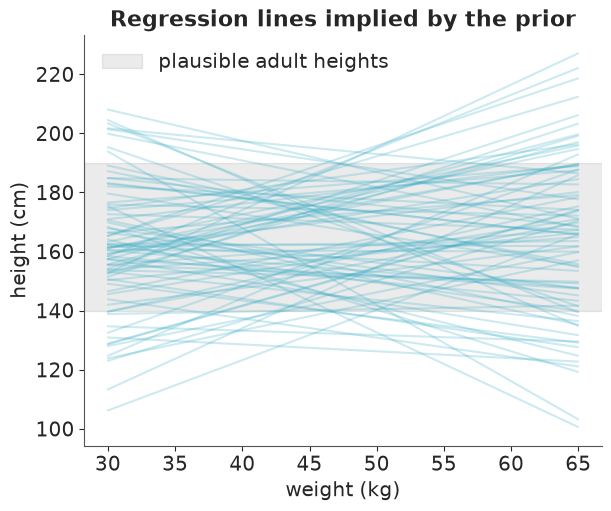

In [7]:
prior = az.extract(idata, group="prior", num_samples=80, random_seed=RANDOM_SEED)
w = np.linspace(-15, 20, 50)

fig, ax = plt.subplots()
for a, b in zip(prior["alpha"].sel(sex="female").values, prior["beta"].values):
    ax.plot(w + weight_mean, a + b * w, color="C0", alpha=0.25)
ax.axhspan(140, 190, color="k", alpha=0.08, label="plausible adult heights")
ax.set(xlabel="weight (kg)", ylabel="height (cm)", title="Regression lines implied by the prior")
ax.legend();

Wide, includes negative slopes we do not really believe in, but nothing crazy. Good enough:
the goal of a weakly-informative prior is to rule out the absurd, not to win the argument.

## 4 · Sample

`pm.sample()` defaults to 4 chains of 1000 kept draws with NUTS. The warm-up length depends on
the sampler: **400** steps under nutpie (the default here), 1000 under PyMC's own NUTS. Pass
`tune=` explicitly when a model needs longer adaptation, and read what actually happened from
`idata.posterior.attrs["tuning_steps"]`.
`idata.update(...)` merges the new groups into the tree we already have.

Another change from older versions: when **nutpie** (a Rust implementation of NUTS) is
installed - and it is in this environment - `pm.sample()` uses it **by default**. The log
line `NUTS[nutpie]` tells you so. Pass `nuts_sampler="pymc"` to get PyMC's own sampler;
the two can behave differently on hard geometries, which is worth remembering whenever
you compare divergence counts with a tutorial.

In [8]:
with model:
    idata.update(pm.sample(random_seed=RANDOM_SEED))

list(idata.children)

NUTS[nutpie]: [alpha, beta, sigma]


['prior',
 'prior_predictive',
 'observed_data',
 'constant_data',
 'posterior',
 'sample_stats']

## 5 · Diagnose before you interpret

The order matters. Until the sampler has demonstrably worked, the numbers mean nothing.

- **`r_hat`** ≤ 1.01: chains agree with one another.
- **`ess_bulk`, `ess_tail`** in the hundreds at least: enough effective draws for means and
  for interval endpoints.
- **Divergences** = 0: NUTS did not hit regions it could not integrate accurately.

In [9]:
# round_to=2 fixes the decimals; the default "auto" keeps 2 significant figures, which is too coarse for alpha
az.summary(idata, ci_kind="hdi", ci_prob=0.94, round_to=2)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[female],151.55,0.34,150.94,152.19,3255.56,3255.31,1.0,0.01,0.00
alpha[male],158.06,0.37,157.37,158.74,3524.44,2969.71,1.0,0.01,0.01
beta,0.64,0.04,0.56,0.72,3097.26,2677.12,1.0,0.00,0.00
sigma,4.29,0.17,3.99,4.62,5203.19,3469.06,1.0,0.00,0.00


divergences: 0


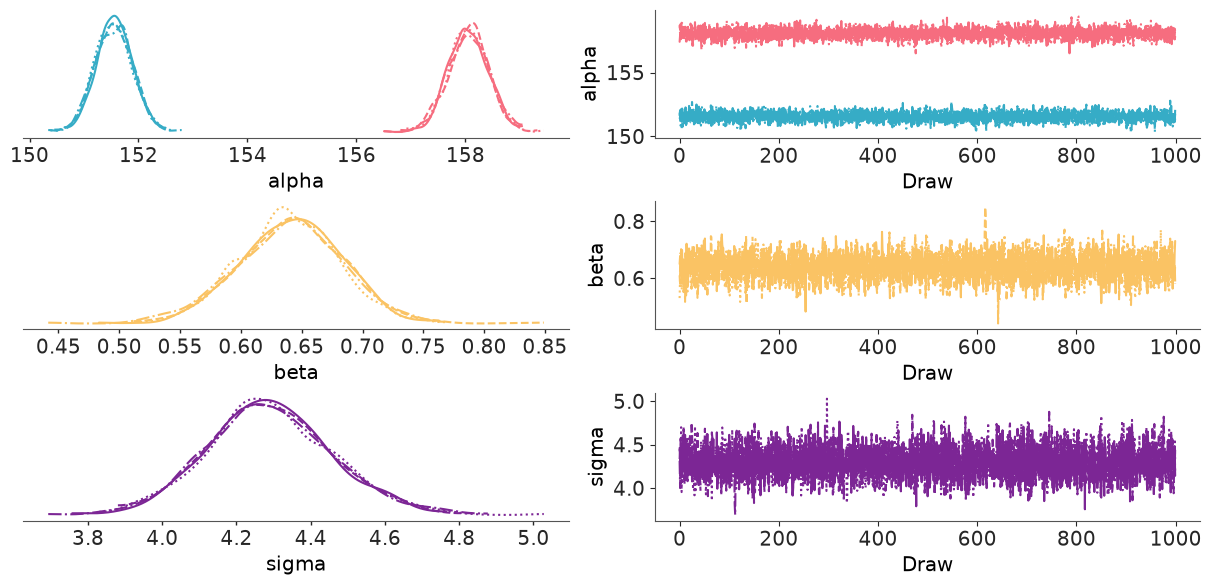

In [10]:
print("divergences:", int(idata.sample_stats["diverging"].sum()))
az.plot_trace_dist(idata);

Rank plots are a sharper diagnostic than trace plots: if the chains target the same
distribution, each chain's ranks are uniform.

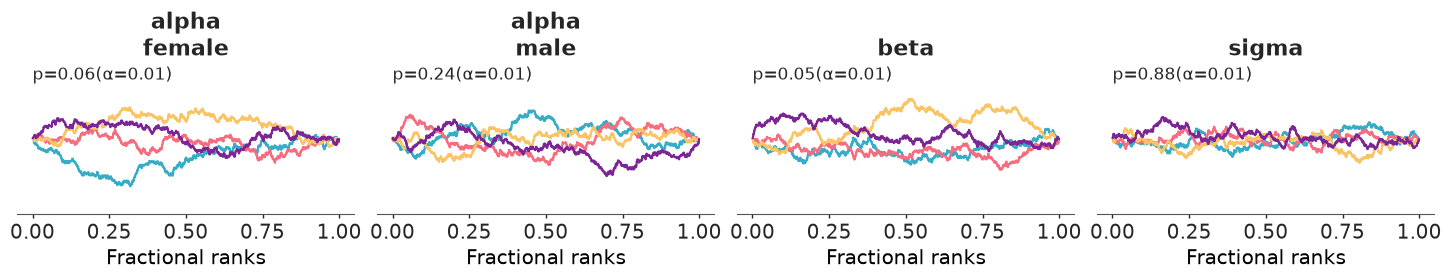

In [11]:
az.plot_rank(idata);

## 6 · Posterior predictive check: can the model reproduce the data?

Sampling: [height]


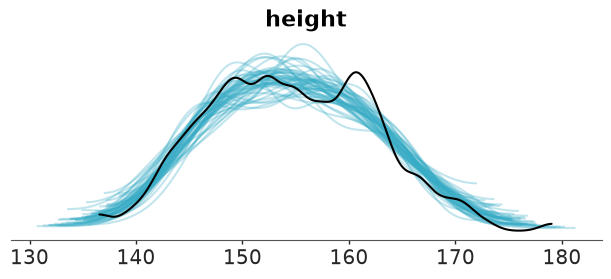

In [12]:
with model:
    pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=RANDOM_SEED)

az.plot_ppc_dist(idata);

The observed distribution (dark line) sits inside the cloud of replicated datasets. A
density overlay is a blunt instrument, so also check a statistic the model was **not**
directly fitted to - here, the tallest person.

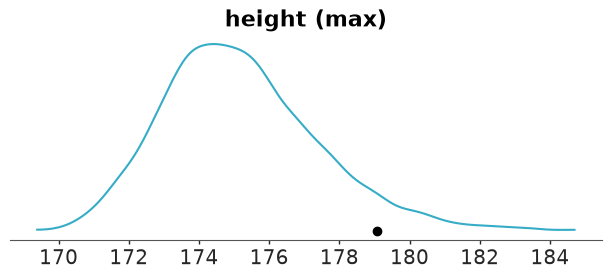

In [13]:
az.plot_ppc_tstat(idata, t_stat="max");

## 7 · Interpret

Work with the posterior as labelled arrays. Because `alpha` has a `sex` dimension, the
difference between sexes is a one-liner, with full uncertainty.

In [14]:
post = idata.posterior
diff = post["alpha"].sel(sex="male") - post["alpha"].sel(sex="female")

print(f"males are taller at equal weight by {float(diff.mean()):.1f} cm")
print("94% HDI:", az.hdi(diff, prob=0.94).values.round(1))
print(f"P(difference > 5 cm) = {float((diff > 5).mean()):.2f}")

males are taller at equal weight by 6.5 cm
94% HDI: [5.5 7.5]
P(difference > 5 cm) = 1.00


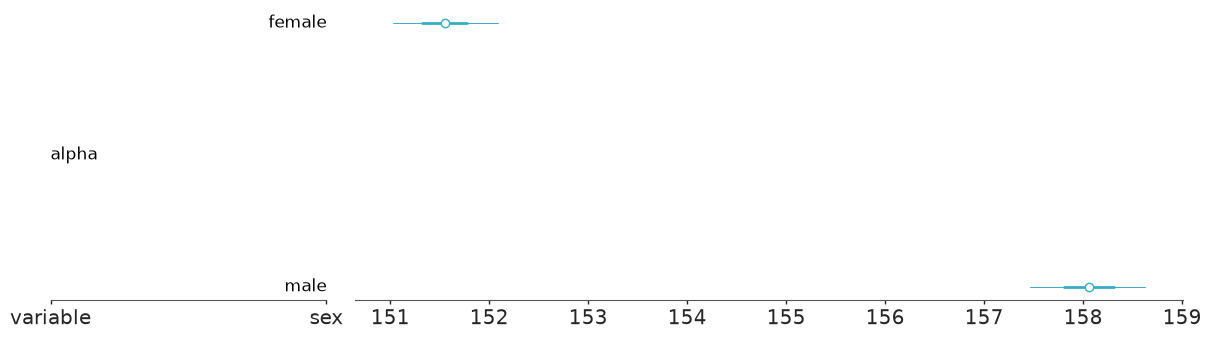

In [15]:
az.plot_forest(idata, var_names=["alpha"], combined=True);

## 8 · Predict for new inputs

Because inputs were registered with `pm.Data`, prediction is: swap the data, sample the
posterior predictive. `predictions=True` stores results in a separate `predictions` group.
New coordinates are needed because the `obs` dimension changes length.

In [16]:
new = pd.DataFrame({"weight": [35.0, 45.0, 55.0, 65.0], "sex": ["female", "female", "male", "male"]})

with model:
    pm.set_data(
        {"weight_c": new.weight - weight_mean, "sex_id": pd.Categorical(new.sex, categories=sexes).codes},
        coords={"obs": new.index},
    )
    pred = pm.sample_posterior_predictive(idata, predictions=True, random_seed=RANDOM_SEED)

pred_height = pred.predictions["height"]
new["mean"] = pred_height.mean(("chain", "draw")).values.round(1)
new[["lo", "hi"]] = az.hdi(pred_height, prob=0.94).values.round(1)
new

Sampling: [height]


,weight,sex,mean,lo,hi
0,35.0,female,145.1,137.1,153.1
1,45.0,female,151.4,143.1,159.2
2,55.0,male,164.4,155.8,172.0
3,65.0,male,170.9,163.0,179.1


Those are **predictive** intervals for an individual (they include $\sigma$), not
intervals for the mean. Know which one your stakeholder is asking for.

## 9 · Criticise and iterate

The model is fine for adults. Include the children and a straight line is hopeless:

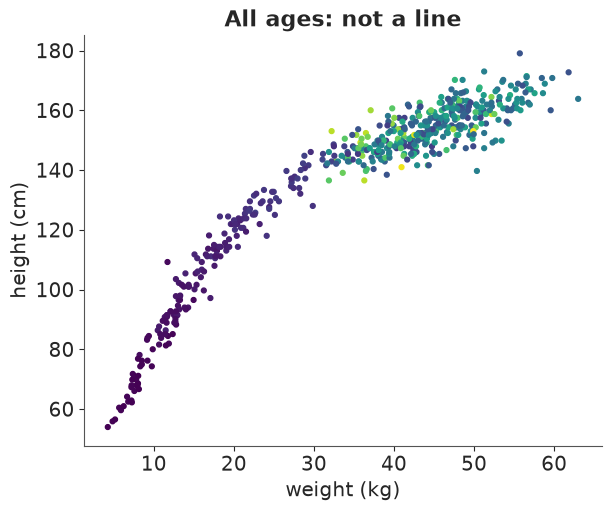

In [17]:
fig, ax = plt.subplots()
ax.scatter(howell.weight, howell.height, c=howell.age, cmap="viridis", s=12)
ax.set(xlabel="weight (kg)", ylabel="height (cm)", title="All ages: not a line");

### Try it yourself

1. Refit on **all ages** with `log(weight)` as the predictor. Is the PPC acceptable?
2. Let the slope differ by sex (`beta` with `dims="sex"`). Does the data support it? Compare
   with `az.compare` (you will need `pm.compute_log_likelihood`).
3. Replace the Normal likelihood with `StudentT`. What happens to `sigma` and to the
   predictive intervals?

Next: **E02** for hierarchical models, or jump into challenge **C01**.